In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.hypothesis_tests import (
    create_claim_indicator,
    calculate_margin,
    calculate_loss_ratio,
    chi_square_test,
    t_test,
    summarize_results
)

In [2]:
df = pd.read_csv("../data/insurance_data_clean.txt")

df.head()

C:\Users\melim\AppData\Local\Temp\ipykernel_7744\2799512812.py:1: DtypeWarning: Columns (0: CapitalOutstanding) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/insurance_data_clean.txt")


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,LossRatio,Margin
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0,21.929825
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0,21.929825
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,0.0,0.000000
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,0.0,512.848070
4,145255,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,0.0,0.000000


In [3]:
df = create_claim_indicator(df)

df = calculate_margin(df)

df = calculate_loss_ratio(df)

df[[
    "HasClaim",
    "Margin",
    "LossRatio"
]].head()

,HasClaim,Margin,LossRatio
0,0,21.929825,0.0
1,0,21.929825,0.0
2,0,0.000000,0.0
3,0,512.848070,0.0
4,0,0.000000,0.0


Hypothesis 1

Province Risk Difference

We’ll use:

KPI → Claim Frequency
Test → Chi-square

Select Provinces

In [4]:
df["Province"].value_counts().head(10)
province_df = df[
    df["Province"].isin([
        "Gauteng",
        "Western Cape"
    ])
]

Test

In [5]:
province_test = chi_square_test(
    province_df,
    group_col="Province",
    target_col="HasClaim"
)

province_test

{'chi2_statistic': np.float64(56.0873842343376),
 'p_value': np.float64(6.93204979415946e-14),
 'degrees_of_freedom': 1,
 'expected_freq': array([[392684.7881915,   1180.2118085],
        [170284.2118085,    511.7881915]])}

Interpret

In [6]:
province_result = summarize_results(
    hypothesis="No risk difference across provinces",
    test_used="Chi-Square",
    p_value=province_test["p_value"]
)

province_result

{'Hypothesis': 'No risk difference across provinces',
 'Test': 'Chi-Square',
 'P-Value': np.float64(0.0),
 'Decision': 'Reject Null Hypothesis'}

Hypothesis 2

Zip Code Risk Difference

We’ll compare:

Claim Severity
Between two major zip codes

Select Top Zip Codes

In [7]:
df["PostalCode"].value_counts().head()

PostalCode
2000    133498
122      49171
7784     28585
299      25546
7405     18518
Name: count, dtype: int64

Extract Claim Severity

In [8]:
claims_df = df[df["TotalClaims"] > 0]

zip_a = 2000
zip_b  = 122

group_a = claims_df[
    claims_df["PostalCode"] == zip_a
]["TotalClaims"]

group_b = claims_df[
    claims_df["PostalCode"] == zip_b
]["TotalClaims"]

Run t-test

In [9]:
zip_risk_test = t_test(
    group_a,
    group_b
)

zip_risk_test

{'t_statistic': np.float64(0.38537639993700307),
 'p_value': np.float64(0.7002080007323606)}

Summarize

In [10]:
zip_risk_result = summarize_results(
    hypothesis="No risk difference between zip codes",
    test_used="T-Test",
    p_value=zip_risk_test["p_value"]
)

zip_risk_result

{'Hypothesis': 'No risk difference between zip codes',
 'Test': 'T-Test',
 'P-Value': np.float64(0.70021),
 'Decision': 'Fail to Reject Null Hypothesis'}

Hypothesis 3
Margin Difference Between Zip Codes

Use:

KPI → Margin
Test → t-test

In [11]:
margin_group_a = df[
    df["PostalCode"] == zip_a
]["Margin"]

margin_group_b = df[
    df["PostalCode"] == zip_b
]["Margin"]

Run Test

In [12]:
margin_test = t_test(
    margin_group_a,
    margin_group_b
)

Summarize

In [13]:
margin_result = summarize_results(
    hypothesis="No significant margin difference between zip codes",
    test_used="T-Test",
    p_value=margin_test["p_value"]
)

margin_result

{'Hypothesis': 'No significant margin difference between zip codes',
 'Test': 'T-Test',
 'P-Value': np.float64(0.24446),
 'Decision': 'Fail to Reject Null Hypothesis'}

Hypothesis 4

Gender Risk Difference
Use:

KPI → Claim Frequency
Test → Chi-square

Filter Gender

In [14]:
gender_df = df[
    df["Gender"].isin([
        "Male",
        "Female"
    ])
]

Run Test

In [15]:
gender_test = chi_square_test(
    gender_df,
    group_col="Gender",
    target_col="HasClaim"
)

Summarize

In [16]:
gender_result = summarize_results(
    hypothesis="No significant risk difference between Women and Men",
    test_used="Chi-Square",
    p_value=gender_test["p_value"]
)

gender_result

{'Hypothesis': 'No significant risk difference between Women and Men',
 'Test': 'Chi-Square',
 'P-Value': np.float64(0.95146),
 'Decision': 'Fail to Reject Null Hypothesis'}

Final Results Table

In [17]:
results_df = pd.DataFrame([
    province_result,
    zip_risk_result,
    margin_result,
    gender_result
])

results_df

,Hypothesis,Test,P-Value,Decision
0,No risk difference across provinces,Chi-Square,0.00000,Reject Null Hypothesis
1,No risk difference between zip codes,T-Test,0.70021,Fail to Reject Null Hypothesis
2,No significant margin difference between zip c...,T-Test,0.24446,Fail to Reject Null Hypothesis
3,No significant risk difference between Women a...,Chi-Square,0.95146,Fail to Reject Null Hypothesis


Business Recommendations Section

Province Risk Recommendation

We reject the null hypothesis for province risk differences.
This suggests that claim occurrence differs significantly across provinces.

Recommendation:
ACIS should consider province-based premium adjustments to reflect regional risk exposure.

Gender Risk Recommendation
If the null hypothesis is rejected, gender may be an important segmentation feature for risk pricing.

Recommendation:
ACIS can incorporate gender-sensitive risk segmentation while ensuring compliance with regulatory constraints.

Visualizations

Claim Frequency by Province

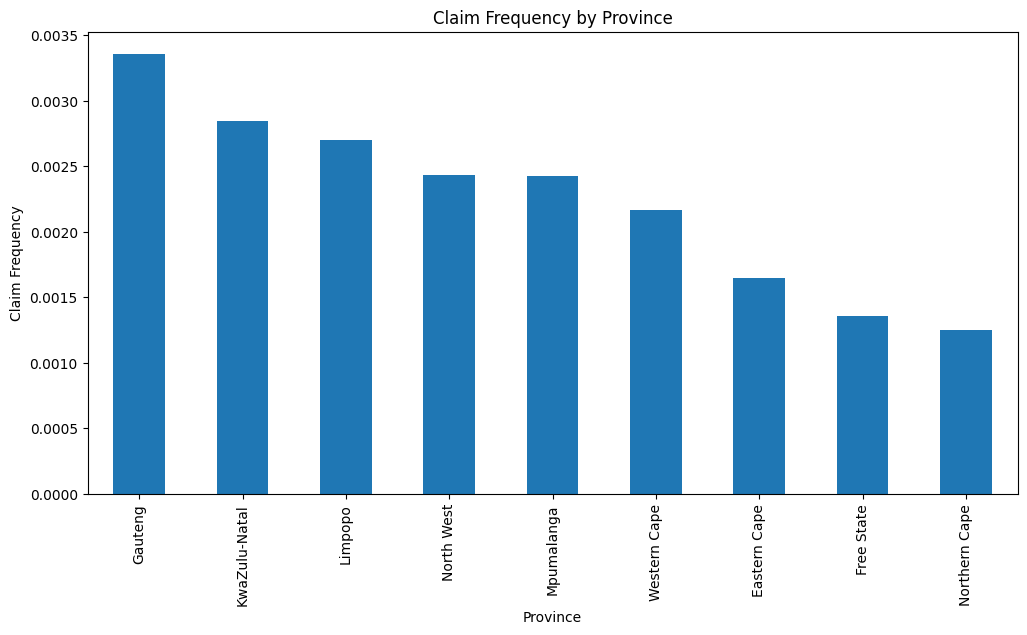

In [18]:
claim_rate = (
    df.groupby("Province")["HasClaim"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

claim_rate.plot(kind="bar")

plt.title("Claim Frequency by Province")

plt.ylabel("Claim Frequency")

plt.show()

Margin Distribution by Gender

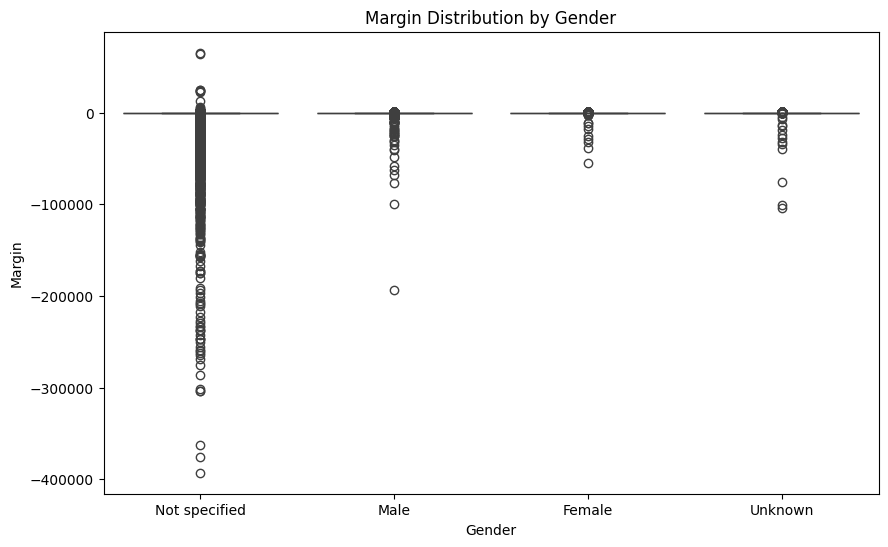

In [19]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Gender",
    y="Margin"
)

plt.title("Margin Distribution by Gender")

plt.show()